In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [3]:
# Make sure 'Telco-Customer-Churn.csv' is uploaded to your Colab environment
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
display(df.head(3))

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
# 1. Fix the hidden blank spaces in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', ''), errors='coerce')

# 2. Drop the tiny amount of missing rows
df = df.dropna()

# 3. Drop customerID as it is useless for prediction
df = df.drop(columns=['customerID'])

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (7032, 20)


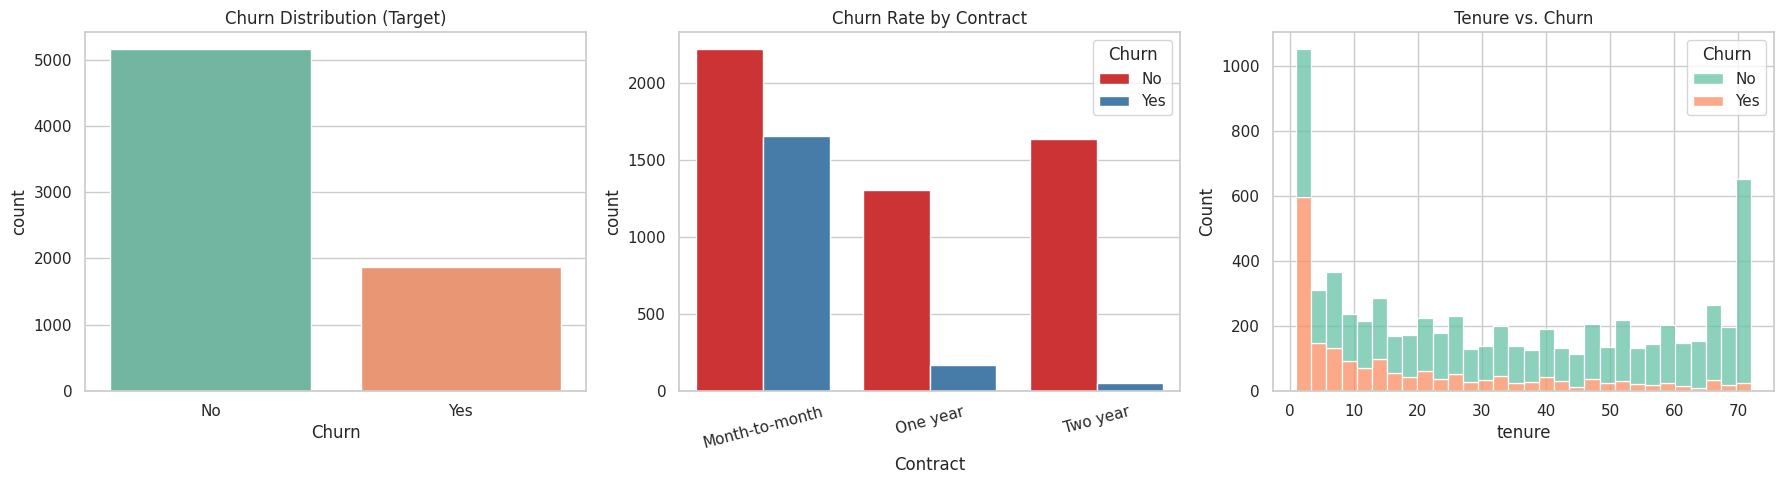

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Insight 1: Class Imbalance
sns.countplot(data=df, x='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn Distribution (Target)')

# Insight 2: Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='Set1')
axes[1].set_title('Churn Rate by Contract')
axes[1].tick_params(axis='x', rotation=15)

# Insight 3: Tenure Distribution
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[2], palette='Set2', bins=30)
axes[2].set_title('Tenure vs. Churn')

plt.tight_layout()
plt.show()

In [6]:
# Convert target variable to 1s and 0s
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (5625, 19)
Testing data: (1407, 19)


In [7]:
# Identify column types dynamically
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

# Create the preprocessor (scales numbers, encodes text)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Build the pipeline (Preprocessor + Model)
# class_weight='balanced' forces the model to care more about finding churners
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train it!
pipeline.fit(X_train, y_train)
print("Model Pipeline successfully trained!")

Model Pipeline successfully trained!


--- Model Metrics ---
Accuracy:  0.7257
Precision: 0.4901
Recall:    0.7941  <-- Most important for your grade
F1-Score:  0.6061



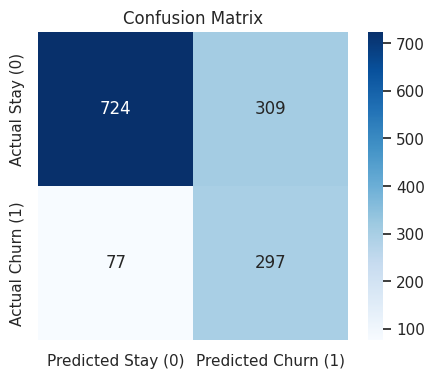

In [8]:
y_pred = pipeline.predict(X_test)

print("--- Model Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}  <-- Most important for your grade")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

# Show Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Stay (0)', 'Actual Churn (1)'])
plt.title('Confusion Matrix')
plt.show()

In [9]:
model_filename = 'model.pkl'
joblib.dump(pipeline, model_filename)

print(f"SUCCESS! Download your '{model_filename}' from the files menu on the left.")

SUCCESS! Download your 'model.pkl' from the files menu on the left.
